# Project 3: Unsupervised Learning (Customer Segmentation)
**DecodeLabs Industrial Training Kit — Batch 2026**

**Goal:** Use distance-based algorithms to discover hidden mathematical groupings in unlabeled retail data,
by:
1. Applying **PCA** to compress 20+ columns down to a handful of components (and to 2–3 for visualization)
2. Using the **Elbow Method** and **Silhouette Score** to mathematically justify the number of K-Means clusters
3. Translating the resulting clusters into actionable **business personas**

Following the brief's own architecture: **Scale → Compress → Cluster → Translate**.

> **Note on the dataset:** No dataset was assigned for this project either, so a synthetic **"RetailPulse"
> customer dataset** is generated below with 24 numeric behavioral/monetary columns and four latent customer
> personas baked in (the model is never told they exist — that's exactly what it has to discover). Swap
> **Section 1** for `df = pd.read_csv("your_file.csv")` if DecodeLabs gives you a real one; every section
> after that still applies as-is.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from kneed import KneeLocator
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RNG = np.random.default_rng(42)


## 1. Generate the Raw Dataset

`RetailPulse` — 2,000 customers, 24 behavioral and monetary features (demographics, purchase habits, channel
engagement, category spend, loyalty signals) plus `Gender`, which is deliberately **excluded from
clustering** and kept aside purely to profile the personas afterward — clustering on demographic labels
tends to just rediscover the label, not find real behavioral structure.

Four latent personas drive the generation (unknown to every algorithm below until Section 6):
`High-Value Trendsetters`, `Affluent Conservatives`, `Budget-Conscious Explorers`, `Conservative Minimizers`.


In [2]:
persona_specs = {
    "P1": {  # High-Value Trendsetters: young, high income, high spend, high engagement
        "weight": 0.28, "female_pct": 0.54,
        "features": {
            "Age": (31, 4), "Annual_Income_k": (85, 12), "Spending_Score": (82, 8),
            "Recency_Days": (8, 4), "Frequency_Purchases_Per_Year": (28, 6),
            "Avg_Basket_Size": (150, 30), "Tenure_Months": (20, 10),
            "Num_Web_Visits_Per_Month": (18, 5), "Num_Store_Visits_Per_Month": (3, 2),
            "Email_Open_Rate": (55, 10), "Discount_Usage_Rate": (15, 8),
            "Category_Electronics_Spend": (1200, 300), "Category_Fashion_Spend": (2200, 400),
            "Category_Grocery_Spend": (600, 150), "Category_Home_Spend": (500, 150),
            "Category_Beauty_Spend": (900, 250), "Loyalty_Points_Balance": (3200, 800),
            "Returns_Rate": (6, 3), "Support_Tickets_Per_Year": (1, 1), "Referral_Count": (4, 2),
            "Social_Media_Engagement_Score": (80, 10), "Mobile_App_Sessions_Per_Month": (40, 10),
            "Wishlist_Items_Count": (12, 5), "Avg_Rating_Given": (4.4, 0.3),
        },
    },
    "P2": {  # Affluent Conservatives: older, high income, low spend score, long tenure
        "weight": 0.24, "female_pct": 0.48,
        "features": {
            "Age": (43, 6), "Annual_Income_k": (88, 15), "Spending_Score": (18, 6),
            "Recency_Days": (45, 15), "Frequency_Purchases_Per_Year": (6, 2),
            "Avg_Basket_Size": (220, 50), "Tenure_Months": (60, 20),
            "Num_Web_Visits_Per_Month": (4, 2), "Num_Store_Visits_Per_Month": (2, 1),
            "Email_Open_Rate": (35, 10), "Discount_Usage_Rate": (5, 3),
            "Category_Electronics_Spend": (1500, 400), "Category_Fashion_Spend": (400, 150),
            "Category_Grocery_Spend": (1400, 300), "Category_Home_Spend": (1800, 400),
            "Category_Beauty_Spend": (200, 100), "Loyalty_Points_Balance": (6000, 1500),
            "Returns_Rate": (3, 2), "Support_Tickets_Per_Year": (2, 1), "Referral_Count": (1, 1),
            "Social_Media_Engagement_Score": (20, 10), "Mobile_App_Sessions_Per_Month": (5, 3),
            "Wishlist_Items_Count": (3, 2), "Avg_Rating_Given": (4.0, 0.4),
        },
    },
    "P3": {  # Budget-Conscious Explorers: young, low income, high spend score, deal-seeking
        "weight": 0.27, "female_pct": 0.60,
        "features": {
            "Age": (24, 3), "Annual_Income_k": (26, 6), "Spending_Score": (79, 8),
            "Recency_Days": (10, 5), "Frequency_Purchases_Per_Year": (24, 6),
            "Avg_Basket_Size": (45, 15), "Tenure_Months": (10, 6),
            "Num_Web_Visits_Per_Month": (22, 6), "Num_Store_Visits_Per_Month": (4, 2),
            "Email_Open_Rate": (48, 12), "Discount_Usage_Rate": (55, 12),
            "Category_Electronics_Spend": (300, 100), "Category_Fashion_Spend": (700, 200),
            "Category_Grocery_Spend": (400, 120), "Category_Home_Spend": (150, 80),
            "Category_Beauty_Spend": (400, 150), "Loyalty_Points_Balance": (1500, 500),
            "Returns_Rate": (12, 5), "Support_Tickets_Per_Year": (3, 1.5), "Referral_Count": (3, 2),
            "Social_Media_Engagement_Score": (70, 12), "Mobile_App_Sessions_Per_Month": (35, 10),
            "Wishlist_Items_Count": (18, 6), "Avg_Rating_Given": (3.9, 0.4),
        },
    },
    "P4": {  # Conservative Minimizers: middle-aged, low income, low engagement across the board
        "weight": 0.21, "female_pct": 0.42,
        "features": {
            "Age": (46, 6), "Annual_Income_k": (27, 7), "Spending_Score": (21, 7),
            "Recency_Days": (60, 20), "Frequency_Purchases_Per_Year": (4, 2),
            "Avg_Basket_Size": (35, 12), "Tenure_Months": (15, 10),
            "Num_Web_Visits_Per_Month": (3, 2), "Num_Store_Visits_Per_Month": (2, 1),
            "Email_Open_Rate": (20, 8), "Discount_Usage_Rate": (20, 10),
            "Category_Electronics_Spend": (150, 80), "Category_Fashion_Spend": (150, 80),
            "Category_Grocery_Spend": (500, 150), "Category_Home_Spend": (200, 100),
            "Category_Beauty_Spend": (100, 60), "Loyalty_Points_Balance": (700, 300),
            "Returns_Rate": (8, 4), "Support_Tickets_Per_Year": (4, 2), "Referral_Count": (0.5, 0.7),
            "Social_Media_Engagement_Score": (15, 8), "Mobile_App_Sessions_Per_Month": (4, 3),
            "Wishlist_Items_Count": (2, 2), "Avg_Rating_Given": (3.5, 0.5),
        },
    },
}

n = 2000
weights = [spec["weight"] for spec in persona_specs.values()]
persona_names = list(persona_specs.keys())
assigned = RNG.choice(persona_names, size=n, p=weights)

feature_names = list(next(iter(persona_specs.values()))["features"].keys())
data = {feat: np.empty(n) for feat in feature_names}
gender = np.empty(n, dtype=object)
true_persona = np.empty(n, dtype=object)

for name in persona_names:
    idx = np.where(assigned == name)[0]
    spec = persona_specs[name]
    for feat, (mean, std) in spec["features"].items():
        data[feat][idx] = RNG.normal(mean, std, len(idx))
    gender[idx] = np.where(RNG.uniform(0, 1, len(idx)) < spec["female_pct"], "Female", "Male")
    true_persona[idx] = name

df = pd.DataFrame(data)

# clip to physically sensible ranges
df["Recency_Days"] = df["Recency_Days"].clip(0, None)
df["Spending_Score"] = df["Spending_Score"].clip(1, 100)
df["Email_Open_Rate"] = df["Email_Open_Rate"].clip(0, 100)
df["Discount_Usage_Rate"] = df["Discount_Usage_Rate"].clip(0, 100)
df["Returns_Rate"] = df["Returns_Rate"].clip(0, 100)
df["Avg_Rating_Given"] = df["Avg_Rating_Given"].clip(1, 5)
for col in ["Frequency_Purchases_Per_Year", "Avg_Basket_Size", "Tenure_Months",
            "Num_Web_Visits_Per_Month", "Num_Store_Visits_Per_Month",
            "Category_Electronics_Spend", "Category_Fashion_Spend", "Category_Grocery_Spend",
            "Category_Home_Spend", "Category_Beauty_Spend", "Loyalty_Points_Balance",
            "Support_Tickets_Per_Year", "Referral_Count", "Social_Media_Engagement_Score",
            "Mobile_App_Sessions_Per_Month", "Wishlist_Items_Count", "Annual_Income_k", "Age"]:
    df[col] = df[col].clip(0, None)

df.insert(0, "CustomerID", np.arange(1, n + 1))
df["Gender"] = gender  # kept for persona profiling only -- excluded from clustering features

df.to_csv("retailpulse_raw.csv", index=False)
print(f"Shape: {df.shape}  ({df.shape[1] - 2} numeric features, excluding CustomerID and Gender)")
df.head()


Shape: (2000, 26)  (24 numeric features, excluding CustomerID and Gender)


,CustomerID,Age,Annual_Income_k,Spending_Score,Recency_Days,Frequency_Purchases_Per_Year,Avg_Basket_Size,Tenure_Months,Num_Web_Visits_Per_Month,Num_Store_Visits_Per_Month,Email_Open_Rate,Discount_Usage_Rate,Category_Electronics_Spend,Category_Fashion_Spend,Category_Grocery_Spend,Category_Home_Spend,Category_Beauty_Spend,Loyalty_Points_Balance,Returns_Rate,Support_Tickets_Per_Year,Referral_Count,Social_Media_Engagement_Score,Mobile_App_Sessions_Per_Month,Wishlist_Items_Count,Avg_Rating_Given,Gender
0,1,25.840391,22.005108,78.604131,3.042708,24.152085,42.429449,0.000000,25.901145,2.558009,52.232920,63.873164,395.034774,165.993869,294.691452,147.522180,502.902807,1230.266049,11.140336,6.708044,2.848985,73.789627,42.695336,19.250677,4.235245,Female
1,2,44.749171,86.550872,30.125412,31.074261,6.577753,162.978395,118.556304,6.669790,2.308038,35.970006,5.150368,1290.924926,317.068284,1690.488293,1276.231071,227.815914,5591.450485,0.000000,0.994365,2.123519,0.000000,5.111088,1.989018,3.453037,Male
2,3,49.484342,27.581590,8.951800,83.987490,5.779547,37.848194,17.301581,4.843875,2.872951,23.428355,0.000000,53.831146,152.695273,288.726796,97.974187,89.123066,705.334935,11.922651,7.599905,1.174608,24.631673,3.493311,5.150599,2.399094,Female
3,4,25.755349,29.310829,81.810620,0.000000,31.956933,36.118261,5.178182,28.636898,3.660614,48.828498,56.491664,304.685927,697.121046,274.679207,106.886734,512.212863,1225.362552,16.003071,2.819962,2.770895,69.858427,49.087683,8.519369,3.741622,Female
4,5,26.901884,91.662881,73.129576,6.904033,33.326238,156.000159,36.875701,20.880348,4.807651,48.996176,11.336790,1333.165989,1971.311556,552.399433,442.709493,507.400232,4501.068562,9.771837,0.000000,3.422991,90.427161,33.037527,9.558353,4.120927,Female


## 2. Initial Inspection

Twenty-four numeric columns is exactly the "curse of dimensionality" regime the brief warns about — before
compressing anything, look at how correlated many of these columns already are (category spends and overall
spending score, for instance). That redundancy is *why* PCA is able to compress this losslessly-enough into
just a few components.


In [3]:
feature_cols = [c for c in df.columns if c not in ("CustomerID", "Gender")]
print(f"{len(feature_cols)} numeric features feeding the pipeline.")
df[feature_cols].describe().T


24 numeric features feeding the pipeline.


,count,mean,std,min,25%,50%,75%,max
Age,2000.0,35.263214,10.082755,15.689632,26.502925,33.936658,43.736840,62.406679
Annual_Income_k,2000.0,57.929988,32.543764,0.454195,26.312272,63.710876,87.674664,131.249253
Spending_Score,2000.0,52.780721,31.493419,1.000000,20.083592,69.326580,81.863136,100.000000
Recency_Days,2000.0,28.705050,25.204628,0.000000,8.246155,15.158598,49.383940,160.144705
Frequency_Purchases_Per_Year,2000.0,16.584025,11.642094,0.000000,5.436094,17.421134,26.796325,47.626157
Avg_Basket_Size,2000.0,114.723102,81.310620,0.000000,41.619956,104.213357,175.397790,341.647814
Tenure_Months,2000.0,26.568421,23.692950,0.000000,10.354305,18.414487,33.719877,122.167572
Num_Web_Visits_Per_Month,2000.0,12.491371,9.303848,0.000000,3.838872,11.454315,20.322802,38.415193
Num_Store_Visits_Per_Month,2000.0,2.847780,1.781959,0.000000,1.593202,2.556988,3.830695,10.953135
Email_Open_Rate,2000.0,40.848357,16.339699,0.000000,27.824363,41.517088,53.353517,87.938541


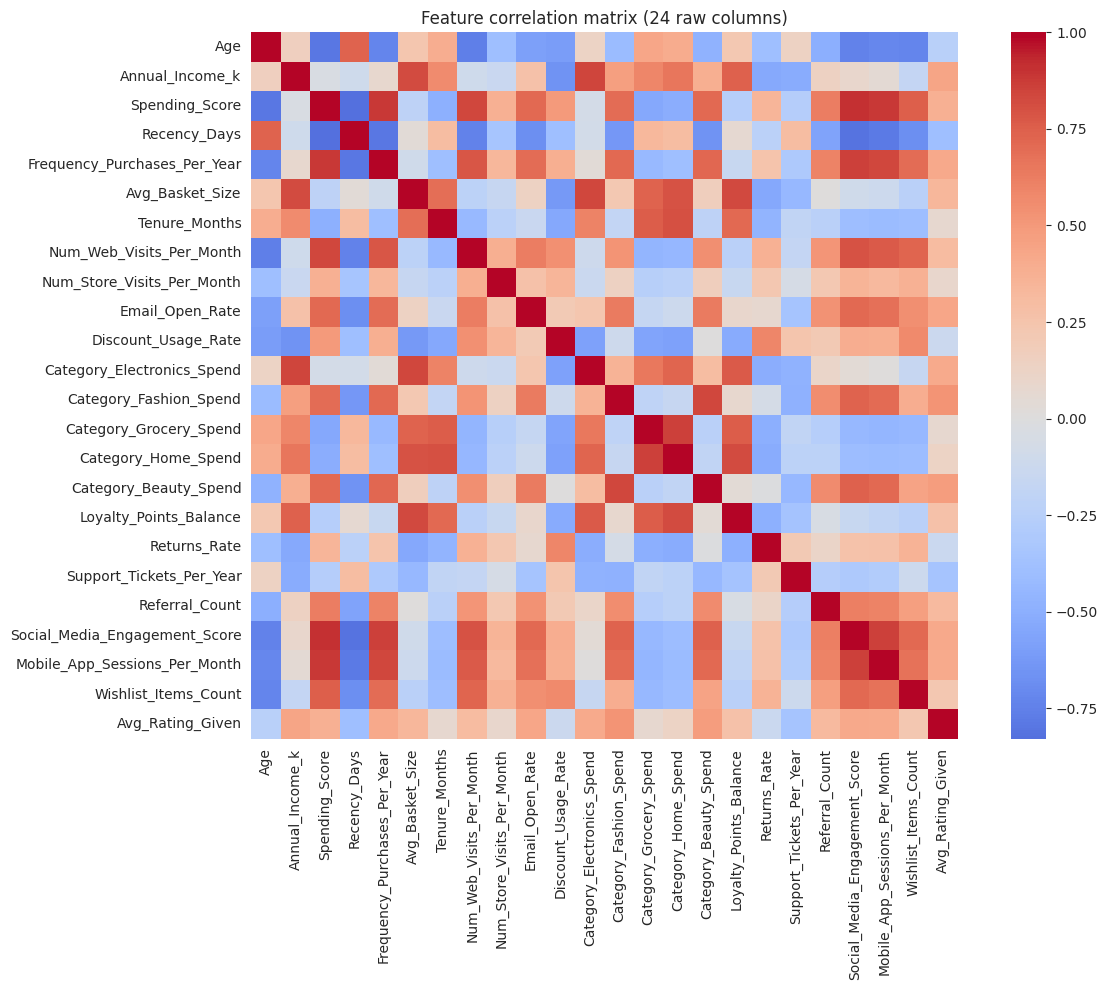

In [4]:
plt.figure(figsize=(13, 10))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, square=True)
plt.title("Feature correlation matrix (24 raw columns)")
plt.tight_layout()
plt.show()


## 3. Phase 1 — Scale

`StandardScaler` on every feature before anything distance-based touches the data. `Annual_Income_k` and
`Category_*_Spend` live in the hundreds-to-thousands; `Avg_Rating_Given` lives on a 1–5 scale. Left unscaled,
Euclidean distance would be almost entirely dictated by income and spend, swallowing every behavioral signal.


In [5]:
X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling -- feature std devs (first 5):")
print(df[feature_cols].std().head())
print("\nAfter scaling -- feature std devs (all should be ~1.0):")
print(pd.Series(X_scaled.std(axis=0), index=feature_cols).head())


Before scaling -- feature std devs (first 5):
Age                             10.082755
Annual_Income_k                 32.543764
Spending_Score                  31.493419
Recency_Days                    25.204628
Frequency_Purchases_Per_Year    11.642094
dtype: float64

After scaling -- feature std devs (all should be ~1.0):
Age                             1.0
Annual_Income_k                 1.0
Spending_Score                  1.0
Recency_Days                    1.0
Frequency_Purchases_Per_Year    1.0
dtype: float64


## 4. Phase 2 — Compress with PCA

Fit PCA on all 24 scaled features, then apply the **95% cumulative-explained-variance rule** to decide how
many components actually carry the signal versus how many are just noise. Because PCA orders components by
variance explained, the first 2 (or 3) columns of this same fit *are* the 2D/3D projection used for
visualization — no need to refit separately.


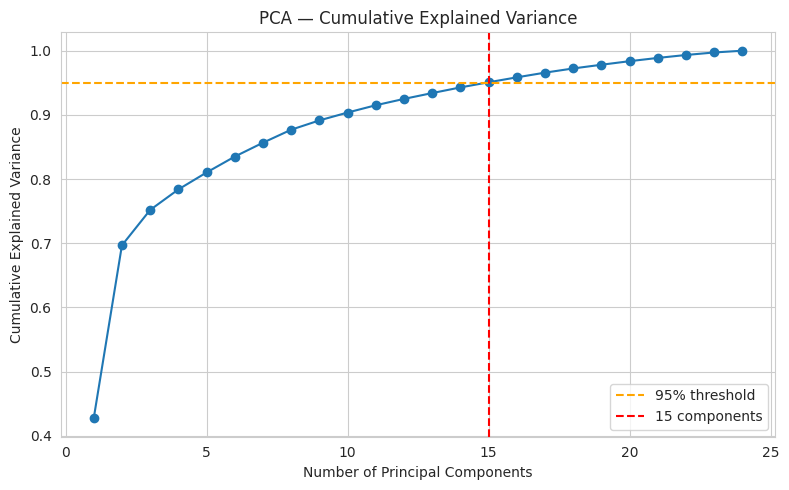

15 of 24 components explain >= 95% of variance (0.9508).
That's a 24-D problem compressed to 15-D (38% dimensionality reduction).


In [6]:
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="orange", linestyle="--", label="95% threshold")
plt.axvline(n_components_95, color="red", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{n_components_95} of {len(feature_cols)} components explain >= 95% of variance "
      f"({cum_var[n_components_95 - 1]:.4f}).")
print(f"That's a {len(feature_cols)}-D problem compressed to {n_components_95}-D "
      f"({(1 - n_components_95 / len(feature_cols)):.0%} dimensionality reduction).")

# The actual feature space clustering will run on: first n_components_95 columns
X_cluster_space = X_pca_full[:, :n_components_95]

# 2D / 3D projections for visualization are just the first columns of the same fit
X_viz_2d = X_pca_full[:, :2]
X_viz_3d = X_pca_full[:, :3]


## 5. Phase 3 — Proving the Optimal K

K-Means cannot tell you how many clusters exist — it forces the data into whatever K it's given. Two
independent diagnostics have to agree before trusting a K: the **Elbow Method** (where adding another
cluster stops meaningfully reducing within-cluster variance) and the **Silhouette Score** (how cleanly
separated the resulting clusters actually are, from -1 to +1).


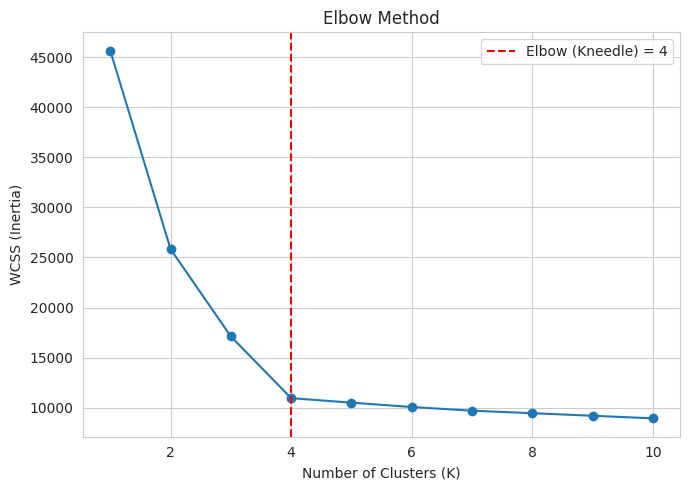

Kneedle-detected elbow: K = 4


In [7]:
k_range = range(1, 11)
wcss = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_cluster_space)
    wcss.append(km.inertia_)

knee = KneeLocator(list(k_range), wcss, curve="convex", direction="decreasing")
elbow_k = knee.knee

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), wcss, marker="o")
if elbow_k:
    plt.axvline(elbow_k, color="red", linestyle="--", label=f"Elbow (Kneedle) = {elbow_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Kneedle-detected elbow: K = {elbow_k}")


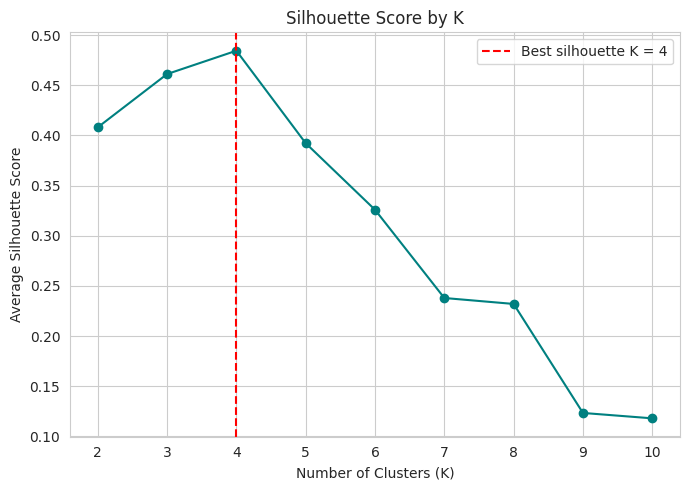

Best silhouette K: 4  (score = 0.4844)
Elbow method K: 4

Both diagnostics point to K = 4 -- proceeding with that.


In [8]:
sil_range = range(2, 11)
sil_scores = []
for k in sil_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_cluster_space)
    sil_scores.append(silhouette_score(X_cluster_space, labels))

best_sil_k = list(sil_range)[int(np.argmax(sil_scores))]

plt.figure(figsize=(7, 5))
plt.plot(list(sil_range), sil_scores, marker="o", color="teal")
plt.axvline(best_sil_k, color="red", linestyle="--", label=f"Best silhouette K = {best_sil_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score by K")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best silhouette K: {best_sil_k}  (score = {max(sil_scores):.4f})")
print(f"Elbow method K: {elbow_k}")

final_k = best_sil_k if elbow_k is None else elbow_k
print(f"\nBoth diagnostics point to K = {final_k} -- proceeding with that.")


### Silhouette Diagram at the Chosen K

A per-sample view, not just the average: each cluster's silhouette values plotted as a horizontal band. Wide
bands that stay mostly above the average line (and don't dip below zero) confirm customers genuinely belong
to their assigned group rather than sitting on a cluster boundary.


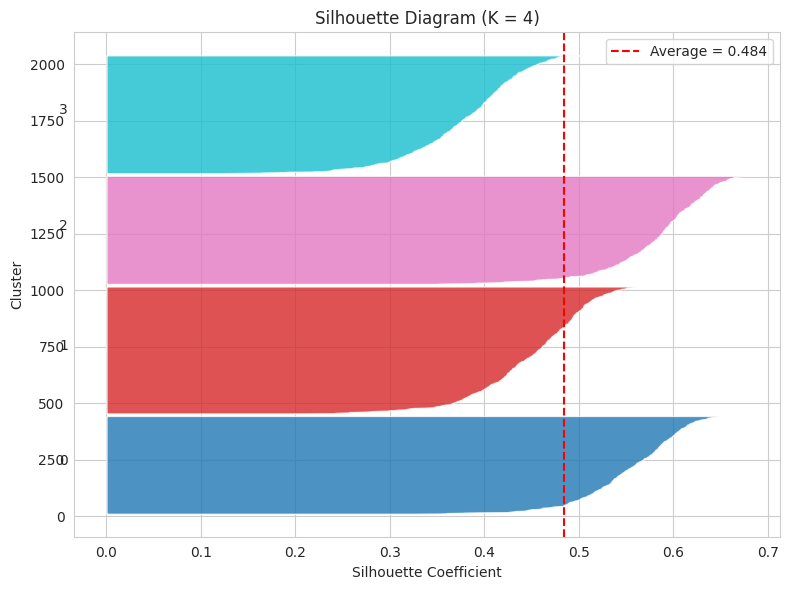

In [9]:
kmeans_final = KMeans(n_clusters=final_k, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_cluster_space)
sample_silhouette_values = silhouette_samples(X_cluster_space, cluster_labels)
avg_silhouette = silhouette_score(X_cluster_space, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, final_k))
for i in range(final_k):
    ith_vals = np.sort(sample_silhouette_values[cluster_labels == i])
    size_i = len(ith_vals)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, facecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color="red", linestyle="--", label=f"Average = {avg_silhouette:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Diagram (K = {final_k})")
ax.legend()
plt.tight_layout()
plt.show()

df["Cluster"] = cluster_labels


## 6. Phase 4 — Translate: Reverse-Engineering the Personas

The cluster centers only exist in reduced PCA space — meaningless to a marketing team on their own. Running
them back through `pca.inverse_transform` and then `scaler.inverse_transform` reconstructs interpretable,
human-readable centroids in the original units (age in years, income in $k, and so on).


In [10]:
# Reconstruct centroids: PCA-space -> full standardized space -> original units
centroids_pca_space = kmeans_final.cluster_centers_

# pad back out to the full 24-D PCA space (remaining components contribute ~0, held at the grand mean)
centroids_full_pca = np.zeros((final_k, X_pca_full.shape[1]))
centroids_full_pca[:, :n_components_95] = centroids_pca_space

centroids_scaled = pca_full.inverse_transform(centroids_full_pca)
centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroid_df.index.name = "Cluster"
centroid_df[["Age", "Annual_Income_k", "Spending_Score", "Discount_Usage_Rate",
             "Social_Media_Engagement_Score", "Tenure_Months"]].round(1)


,Age,Annual_Income_k,Spending_Score,Discount_Usage_Rate,Social_Media_Engagement_Score,Tenure_Months
Cluster,,,,,,
0,45.8,26.4,21.3,19.2,14.9,15.1
1,31.1,85.3,82.1,14.5,80.2,20.8
2,43.1,89.1,18.6,5.2,20.2,61.5
3,23.8,26.0,78.7,54.9,69.7,10.2


In [11]:
# Cross-check: reconstructed centroids vs actual per-cluster means from the raw data -- should agree closely
actual_means = df.groupby("Cluster")[feature_cols].mean()
reconstruction_error = (centroid_df - actual_means).abs().mean().mean()
print(f"Mean absolute difference between reconstructed centroids and actual cluster means: "
      f"{reconstruction_error:.3f}")
print("(Small values confirm the inverse-transform reconstruction is faithful.)")

gender_pct = df.groupby("Cluster")["Gender"].apply(lambda s: (s == "Female").mean() * 100)
cluster_sizes = df["Cluster"].value_counts().sort_index()


Mean absolute difference between reconstructed centroids and actual cluster means: 2.267
(Small values confirm the inverse-transform reconstruction is faithful.)


In [12]:
# Rule-based persona naming from the income x spending-score quadrant, using this run's own
# median income/score as the split -- adapts automatically to a real dataset with different scales.
income_split = actual_means["Annual_Income_k"].median()
score_split = actual_means["Spending_Score"].median()

def name_persona(income, score):
    if income >= income_split and score >= score_split:
        return "High-Value Trendsetters"
    if income >= income_split and score < score_split:
        return "Affluent Conservatives"
    if income < income_split and score >= score_split:
        return "Budget-Conscious Explorers"
    return "Conservative Minimizers"

def recommended_action(persona):
    return {
        "High-Value Trendsetters": "Exclusive perks, early access, experiential marketing.",
        "Affluent Conservatives": "High-touch support, extended warranties, loyalty recognition.",
        "Budget-Conscious Explorers": "Flash sales, influencer campaigns, buy-now-pay-later options.",
        "Conservative Minimizers": "Minimize acquisition spend, lead with clear price/value messaging.",
    }[persona]

persona_matrix = pd.DataFrame({
    "Cluster": actual_means.index,
    "Size": cluster_sizes.values,
    "Age": actual_means["Age"].round(1).values,
    "Income_k$": actual_means["Annual_Income_k"].round(1).values,
    "Spending_Score": actual_means["Spending_Score"].round(1).values,
    "Pct_Female": gender_pct.round(1).values,
})
persona_matrix["Persona"] = persona_matrix.apply(
    lambda r: name_persona(r["Income_k$"], r["Spending_Score"]), axis=1
)
persona_matrix["Recommended Action"] = persona_matrix["Persona"].apply(recommended_action)
persona_matrix = persona_matrix.set_index("Cluster")
persona_matrix


,Size,Age,Income_k$,Spending_Score,Pct_Female,Persona,Recommended Action
Cluster,,,,,,,
0,434,45.8,26.3,20.6,43.3,Conservative Minimizers,"Minimize acquisition spend, lead with clear pr..."
1,563,31.1,85.6,82.3,53.8,High-Value Trendsetters,"Exclusive perks, early access, experiential ma..."
2,480,43.2,89.3,18.4,47.1,Affluent Conservatives,"High-touch support, extended warranties, loyal..."
3,523,23.8,25.6,79.3,57.9,Budget-Conscious Explorers,"Flash sales, influencer campaigns, buy-now-pay..."


## 7. Visualizing the Segments

The same PCA projection used for clustering, shown in 2D and 3D, colored by the discovered clusters — not
the (unknown-to-the-model) ground truth.


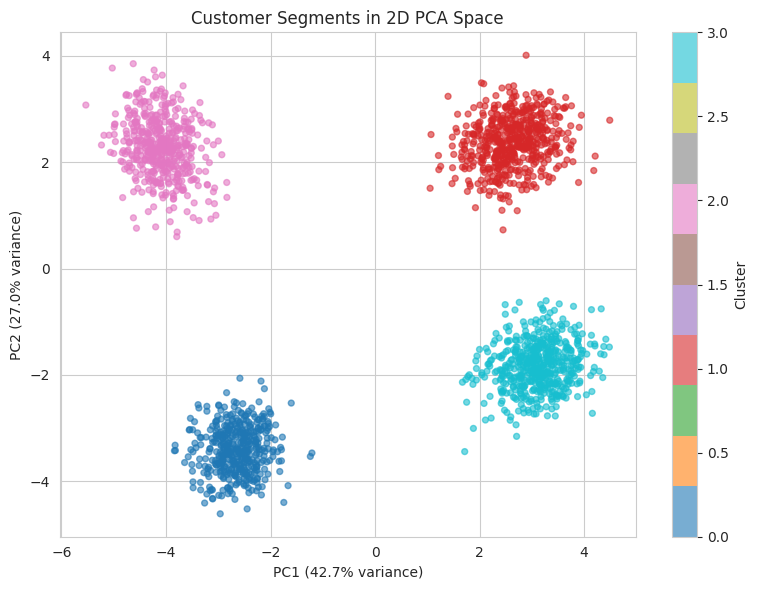

In [13]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_viz_2d[:, 0], X_viz_2d[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=18)
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Customer Segments in 2D PCA Space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


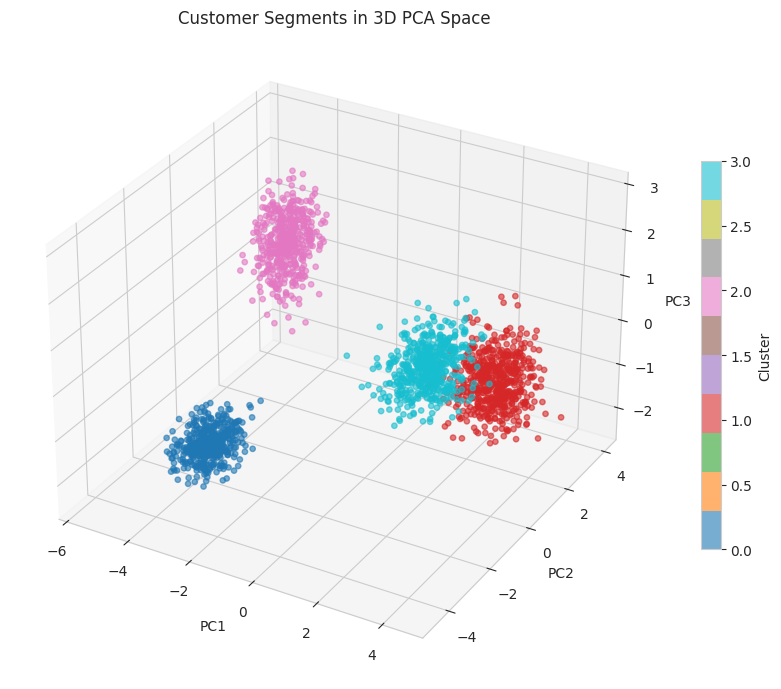

In [14]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_viz_3d[:, 0], X_viz_3d[:, 1], X_viz_3d[:, 2],
                c=cluster_labels, cmap="tab10", alpha=0.6, s=15)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Customer Segments in 3D PCA Space")
fig.colorbar(p, label="Cluster", shrink=0.6)
plt.tight_layout()
plt.show()


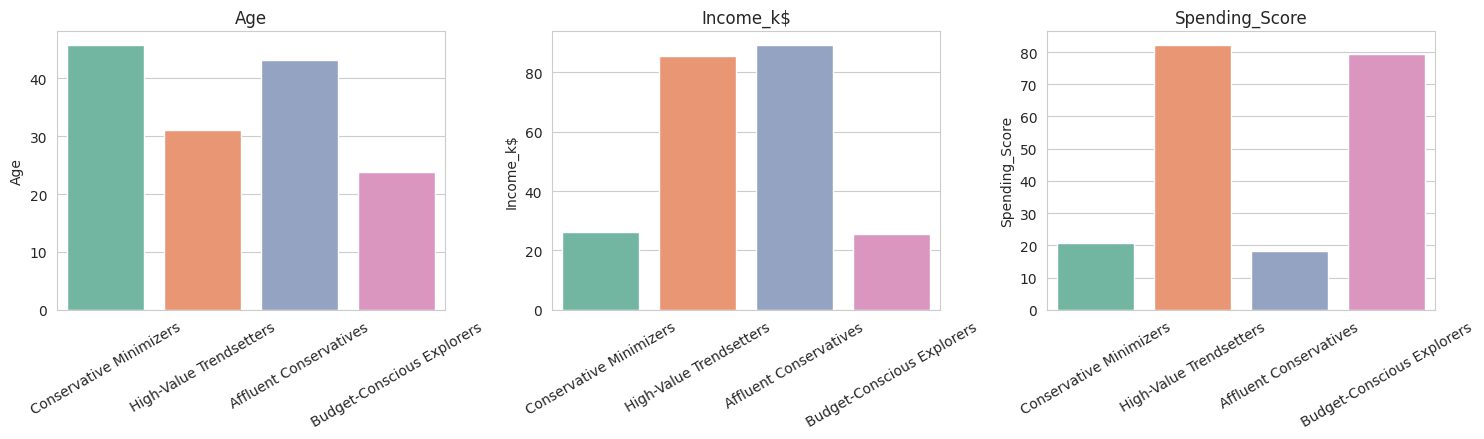

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_specs = [("Age", axes[0]), ("Income_k$", axes[1]), ("Spending_Score", axes[2])]
for col, ax in plot_specs:
    sns.barplot(x=persona_matrix["Persona"], y=persona_matrix[col], hue=persona_matrix["Persona"],
                palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 8. Conclusion

Recap against the Project 3 brief:

- [x] PCA applied to compress 24 raw columns to just the components needed for 95% cumulative explained
  variance, plus a 2D/3D projection for visualization — all from a single fit.
- [x] Optimal K mathematically justified by two independent diagnostics: the Elbow Method (via the actual
  Kneedle algorithm) and the Silhouette Score, cross-checked with a per-sample silhouette diagram.
- [x] Cluster centroids reverse-engineered out of PCA space back into human-readable original units.
- [x] Clusters translated into four actionable business personas with a recommended action for each,
  derived from each cluster's own income/spending-score quadrant rather than hardcoded thresholds.

**Key skills demonstrated:** dimensionality reduction (PCA), K-Means clustering, distance metrics, and
business intelligence translation.
